# Spotify Playlist Clustering

I build a compact K-Means prototype for grouping songs into playlist-like clusters using Spotify audio features.

## 1. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin_min
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
FILE_ID = "1a-JNdTUduvxHU45uS0u_DQ6wirsSZDXG"
DATA_URL = f"https://drive.google.com/uc?id={FILE_ID}"

## 2. Load and prepare data

I keep identifiers for interpretation and use only numeric audio features for clustering.

In [2]:
def load_spotify_data(url: str = DATA_URL) -> pd.DataFrame:
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip()
    return df


def get_feature_frame(
    df: pd.DataFrame,
    metadata_cols=("name", "artist", "id", "html", "type"),
) -> pd.DataFrame:
    numeric = df.drop(columns=list(metadata_cols), errors="ignore")
    numeric = numeric.select_dtypes(include="number")
    numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")
    return numeric.fillna(numeric.median(numeric_only=True))


songs_df = load_spotify_data()
songs_features = get_feature_frame(songs_df)

print(f"Rows: {songs_df.shape[0]:,}")
print(f"Audio features: {songs_features.shape[1]}")
display(songs_df.head())
display(songs_features.describe().T.round(3))

Rows: 5,235
Audio features: 14


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5235.0,2617.000,1511.359,0.0,1308.500,2617.000,3925.500,5234.000
danceability,5235.0,0.510,0.218,0.0,0.309,0.539,0.688,0.967
energy,5235.0,0.654,0.288,0.0,0.479,0.738,0.893,1.000
key,5235.0,5.254,3.572,0.0,2.000,5.000,8.000,11.000
loudness,5235.0,-9.338,6.295,-60.0,-11.337,-7.338,-5.264,1.342
mode,5235.0,0.646,0.478,0.0,0.000,1.000,1.000,1.000
speechiness,5235.0,0.083,0.071,0.0,0.039,0.056,0.099,0.918
acousticness,5235.0,0.290,0.356,0.0,0.002,0.095,0.565,0.996
instrumentalness,5235.0,0.257,0.371,0.0,0.000,0.002,0.643,0.985
liveness,5235.0,0.185,0.149,0.0,0.092,0.125,0.237,0.987


## 3. Scaling comparison

I compare several scaling options and keep StandardScaler for the final prototype because K-Means depends on distances.

In [3]:
SCALERS = {
    "raw": None,
    "minmax": MinMaxScaler(),
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "quantile": QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
    "power": PowerTransformer(),
}


def scale_features(X: pd.DataFrame, scaler) -> pd.DataFrame:
    if scaler is None:
        return X.copy()
    scaled = scaler.fit_transform(X)
    return pd.DataFrame(scaled, columns=X.columns, index=X.index)


scaled_frames = {name: scale_features(songs_features, scaler) for name, scaler in SCALERS.items()}

feature = "tempo" if "tempo" in songs_features.columns else songs_features.columns[0]
comparison = pd.concat(
    [frame[feature].rename(name) for name, frame in scaled_frames.items()],
    axis=1,
)
display(comparison.head())

,raw,minmax,standard,robust,quantile,power
0,110.376,0.515800,-0.292147,-0.232633,-0.229019,-0.235735
1,125.039,0.584322,0.221160,0.154816,0.236460,0.279924
2,93.698,0.437862,-0.875994,-0.673325,-0.854371,-0.866925
3,106.802,0.499098,-0.417262,-0.327071,-0.328253,-0.366653
4,120.941,0.565171,0.077701,0.046532,0.075569,0.139074


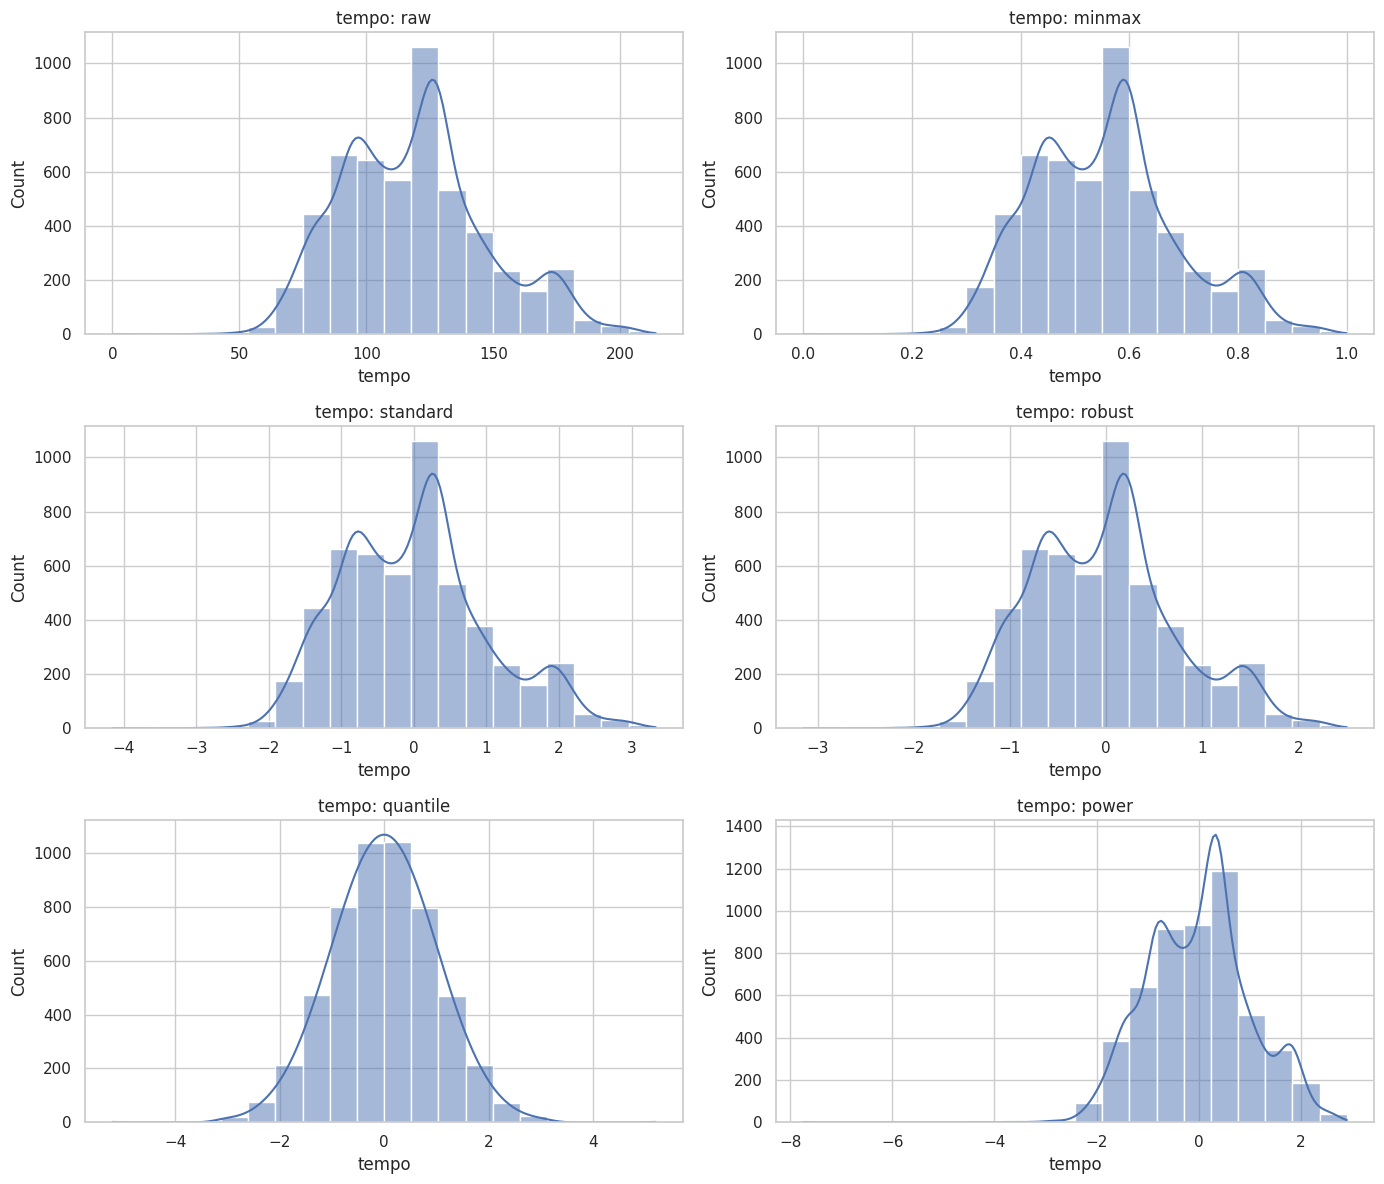

In [4]:
def plot_scaler_histograms(frames: dict[str, pd.DataFrame], feature: str, bins: int = 20) -> None:
    rows = int(np.ceil(len(frames) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).ravel()

    for ax, (name, frame) in zip(axes, frames.items()):
        sns.histplot(frame[feature], bins=bins, kde=True, ax=ax)
        ax.set_title(f"{feature}: {name}")

    for ax in axes[len(frames):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_scaler_histograms(scaled_frames, feature)

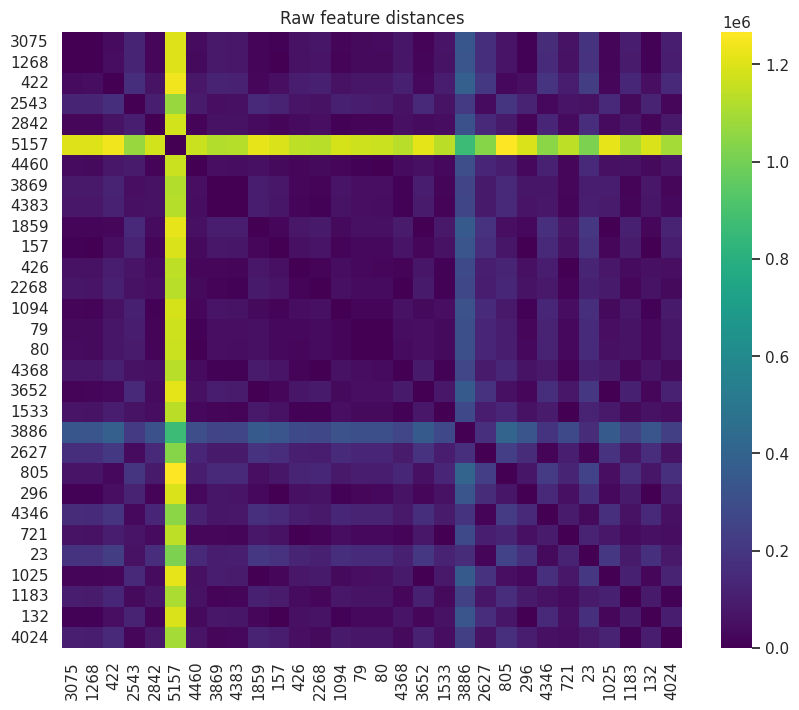

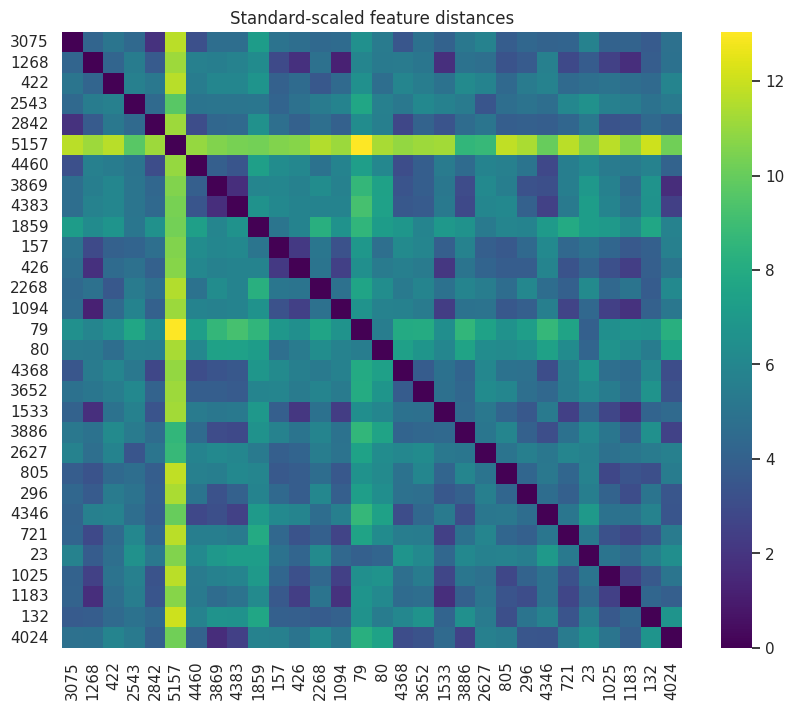

In [5]:
def plot_distance_heatmap(X: pd.DataFrame, title: str, sample_size: int = 30) -> None:
    sample = X.sample(min(sample_size, len(X)), random_state=RANDOM_STATE)
    distances = pd.DataFrame(
        pairwise_distances(sample),
        index=sample.index,
        columns=sample.index,
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(distances, cmap="viridis")
    plt.title(title)
    plt.show()


plot_distance_heatmap(songs_features, "Raw feature distances")
plot_distance_heatmap(scaled_frames["standard"], "Standard-scaled feature distances")

## 4. Estimate cluster count

I compare statistical metrics with the business requirement. The metric-based choice is useful for model quality, while `k=50` is useful for a playlist catalog that feels broad enough for the product.

In [6]:
X = scaled_frames["standard"]


def evaluate_kmeans(X: pd.DataFrame, k_range=range(2, 51)) -> pd.DataFrame:
    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
        })
    return pd.DataFrame(rows)


k_scores = evaluate_kmeans(X)
display(k_scores.sort_values("silhouette", ascending=False).head(10))

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,60140.862478,0.268901,1144.144045,1.652801
1,3,51910.497073,0.186389,1077.407900,1.782017
7,9,37775.207870,0.150920,614.160999,1.701083
6,8,39506.083363,0.149412,638.558817,1.691933
2,4,48367.180605,0.147354,898.483858,2.085509
5,7,41404.706431,0.146188,671.004972,1.783146
3,5,45912.134810,0.144013,779.677787,1.988947
8,10,36185.304227,0.143429,595.306999,1.653412
9,11,35072.404716,0.140226,569.247302,1.748044
4,6,43700.905601,0.139531,708.098341,1.910754


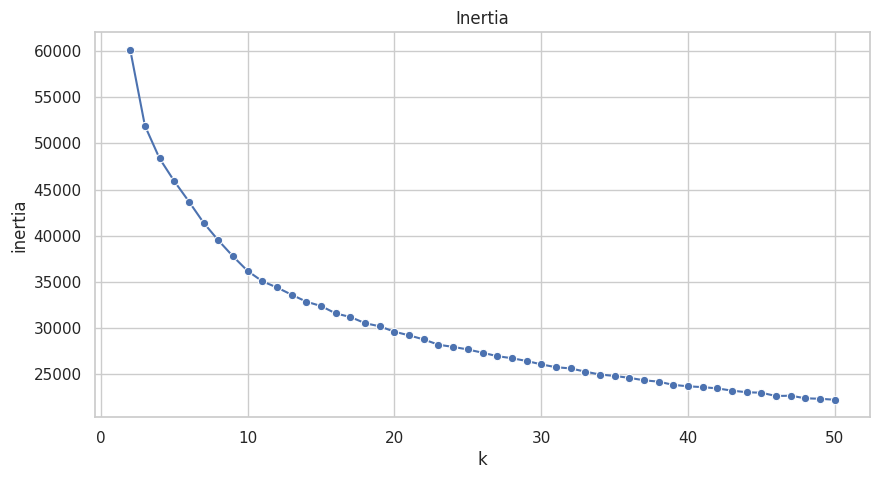

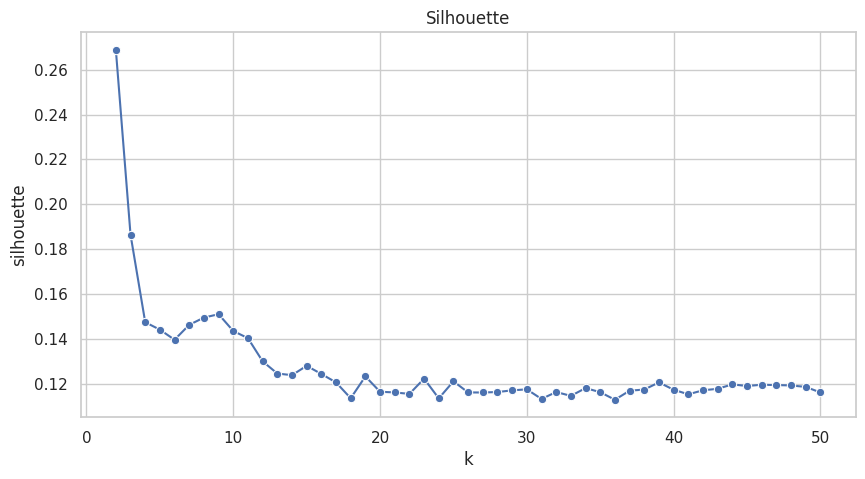

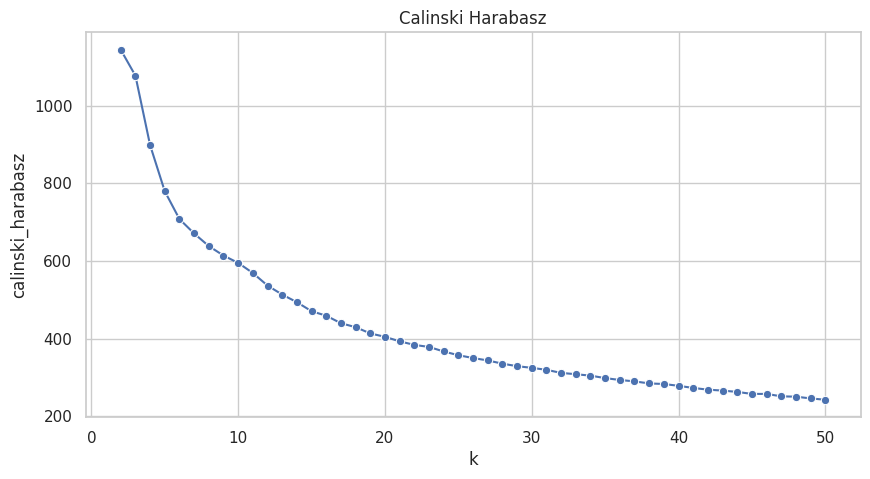

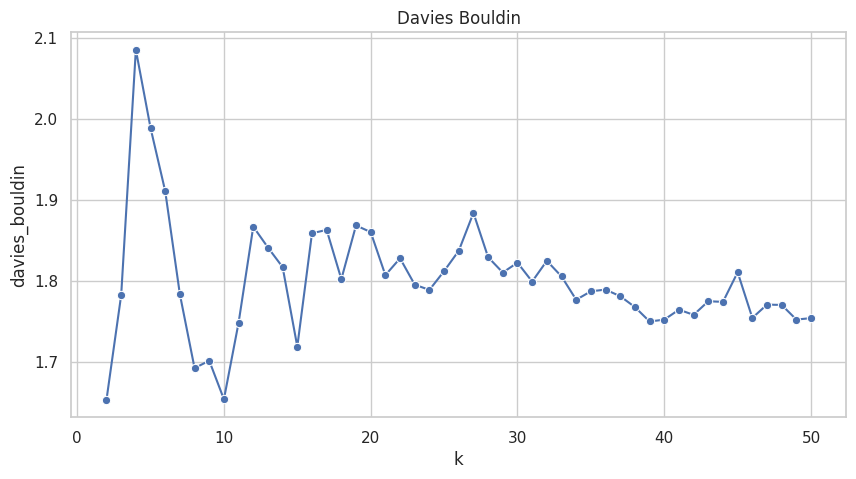

In [7]:
def plot_metric(df: pd.DataFrame, metric: str, ylabel: str | None = None) -> None:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x="k", y=metric, marker="o")
    plt.title(metric.replace("_", " ").title())
    plt.ylabel(ylabel or metric)
    plt.show()


for metric in ["inertia", "silhouette", "calinski_harabasz", "davies_bouldin"]:
    plot_metric(k_scores, metric)

In [8]:
def choose_k(scores: pd.DataFrame, method: str = "silhouette") -> int:
    if method == "silhouette":
        return int(scores.loc[scores["silhouette"].idxmax(), "k"])
    if method == "calinski_harabasz":
        return int(scores.loc[scores["calinski_harabasz"].idxmax(), "k"])
    if method == "davies_bouldin":
        return int(scores.loc[scores["davies_bouldin"].idxmin(), "k"])
    raise ValueError("method must be: silhouette, calinski_harabasz, or davies_bouldin")


METRIC_K = choose_k(k_scores, method="silhouette")
BUSINESS_K = 50

print(f"Metric-selected clusters: {METRIC_K}")
print(f"Business-selected clusters: {BUSINESS_K}")

display(
    k_scores[k_scores["k"].isin([METRIC_K, BUSINESS_K])]
    .sort_values("k")
    .reset_index(drop=True)
)


Metric-selected clusters: 2
Business-selected clusters: 50


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,60140.862478,0.268901,1144.144045,1.652801
1,50,22242.476574,0.116005,242.853416,1.753724


## 5. Build playlist clusters

I use `k=50` for the business-facing prototype. This creates a richer playlist catalog than the metric-selected version and gives Moosic more playlist variety to evaluate.

In [9]:
def cluster_songs(X: pd.DataFrame, k: int) -> tuple[KMeans, pd.Series]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = pd.Series(model.fit_predict(X), index=X.index, name="cluster")
    return model, labels


kmeans_model, cluster_labels = cluster_songs(X, BUSINESS_K)

songs_clusters_df = songs_df.copy()
songs_clusters_df["cluster"] = cluster_labels.values

cluster_sizes = (
    songs_clusters_df["cluster"]
    .value_counts()
    .sort_values()
    .rename_axis("cluster")
    .reset_index(name="songs")
)

display(cluster_sizes)


,cluster,songs
0,20,2
1,43,11
2,46,18
3,44,19
4,22,24
5,15,36
6,36,44
7,38,48
8,10,58
9,26,61


## 6. Business analysis for 50 clusters

I inspect cluster size distribution to check whether 50 playlists are usable. Very small clusters can be valuable niche playlists, but they may also indicate that the model is over-segmenting the catalog.

,songs
count,50.00
mean,104.70
std,56.53
min,2.00
10%,34.80
25%,67.00
50%,97.00
75%,139.75
90%,167.90
max,275.00


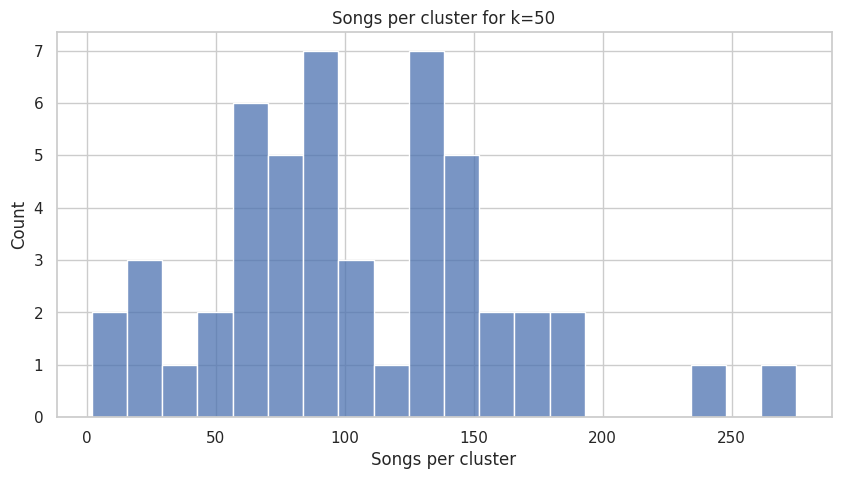

In [10]:
def summarize_cluster_sizes(cluster_sizes: pd.DataFrame) -> pd.DataFrame:
    size_stats = cluster_sizes["songs"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    return size_stats.to_frame("songs").round(2)


display(summarize_cluster_sizes(cluster_sizes))

plt.figure(figsize=(10, 5))
sns.histplot(cluster_sizes["songs"], bins=20)
plt.title("Songs per cluster for k=50")
plt.xlabel("Songs per cluster")
plt.show()


In [11]:
def get_small_cluster(
    cluster_sizes: pd.DataFrame,
    min_size: int = 3,
    max_size: int = 15,
) -> int:
    candidates = cluster_sizes[
        cluster_sizes["songs"].between(min_size, max_size)
    ].sort_values("songs")

    if candidates.empty:
        candidates = cluster_sizes.sort_values("songs")

    return int(candidates.iloc[0]["cluster"])


def list_cluster_songs(
    df: pd.DataFrame,
    cluster: int,
    limit: int = 25,
) -> pd.DataFrame:
    cols = [
        col for col in [
            "name",
            "artist",
            "cluster",
            "danceability",
            "energy",
            "valence",
            "tempo",
        ]
        if col in df.columns
    ]

    return (
        df[df["cluster"] == cluster]
        .sort_values([col for col in ["artist", "name"] if col in df.columns])
        [cols]
        .head(limit)
    )


SMALL_CLUSTER = get_small_cluster(cluster_sizes)

print(f"Small cluster selected for inspection: {SMALL_CLUSTER}")
display(list_cluster_songs(songs_clusters_df, SMALL_CLUSTER))


Small cluster selected for inspection: 43


,name,artist,cluster,danceability,energy,valence,tempo
1950,Vivaldi Variation (Arr. for Piano from Concert...,Antonio Vivaldi,43,0.429,0.25800,0.0972,78.809
2066,A Game of Badminton (feat. Jack Liebeck) ...,Dario Marianelli,43,0.375,0.00406,0.3580,139.682
1861,Wandering II ...,Eydís Evensen,43,0.151,0.15400,0.1340,80.555
108,Coração Vagabundo ...,Gal Costa,43,0.577,0.31200,0.3720,80.698
4681,Der Weg ...,Herbert Grönemeyer,43,0.344,0.24400,0.1910,142.360
1921,"Unaccompanied Cello Suite No. 1 in G major, BW...",Johann Sebastian Bach,43,0.326,0.09930,0.4170,137.274
877,Chances Are - Single Version ...,Johnny Mathis,43,0.310,0.25400,0.2960,77.512
1841,"Bang Bang (My Baby Shot Me Down) - From ""Kill ...",Thibault Cauvin,43,0.476,0.23500,0.1720,121.940
1070,Delilah ...,Tom Jones,43,0.528,0.48200,0.7880,95.820
1889,Lovely ...,TwoPlusFour,43,0.167,0.29000,0.0591,93.905


## 7. Cluster profiles

I summarize each playlist by average audio feature values and representative songs near each centroid.

In [12]:
def build_cluster_profiles(df: pd.DataFrame, features: pd.DataFrame, label_col: str = "cluster") -> pd.DataFrame:
    profile = df.join(features.add_suffix("_raw"))
    audio_cols = [f"{col}_raw" for col in features.columns]
    summary = profile.groupby(label_col)[audio_cols].mean().round(3)
    summary["cluster_size"] = df.groupby(label_col).size()
    return summary.sort_values("cluster_size", ascending=False)


cluster_profiles = build_cluster_profiles(songs_clusters_df, songs_features)
display(cluster_profiles)

,Unnamed: 0_raw,danceability_raw,energy_raw,key_raw,loudness_raw,mode_raw,speechiness_raw,acousticness_raw,instrumentalness_raw,liveness_raw,valence_raw,tempo_raw,duration_ms_raw,time_signature_raw,cluster_size
cluster,,,,,,,,,,,,,,,
11,1216.524,0.654,0.727,7.836,-6.475,1.000,0.054,0.108,0.036,0.143,0.600,112.359,223081.520,4.000,275
24,1104.801,0.688,0.748,1.559,-7.073,1.000,0.050,0.146,0.032,0.159,0.801,121.848,221098.102,3.992,236
6,3898.942,0.262,0.905,8.116,-8.340,1.000,0.107,0.007,0.768,0.177,0.215,109.280,259984.862,4.037,189
27,3930.351,0.280,0.940,5.373,-6.641,1.000,0.125,0.006,0.081,0.180,0.188,110.971,256446.876,4.022,185
1,1560.562,0.551,0.730,1.932,-5.841,1.000,0.050,0.102,0.080,0.140,0.327,122.905,241909.426,4.000,176
47,979.443,0.479,0.767,4.928,-6.939,0.952,0.067,0.253,0.144,0.175,0.715,169.478,195956.575,3.964,167
42,961.788,0.624,0.432,1.545,-10.869,1.000,0.048,0.636,0.057,0.147,0.610,104.064,194711.764,4.000,165
16,1112.255,0.710,0.718,9.137,-6.516,0.000,0.060,0.157,0.065,0.140,0.679,116.442,225817.000,4.007,153
30,4219.533,0.687,0.741,1.191,-5.863,1.000,0.062,0.125,0.038,0.166,0.573,120.729,221254.401,3.987,152


In [13]:
def get_representative_songs(
    df: pd.DataFrame,
    X: pd.DataFrame,
    model: KMeans,
    labels: pd.Series,
    songs_per_cluster: int = 5,
) -> pd.DataFrame:
    nearest_idx, distances = pairwise_distances_argmin_min(model.cluster_centers_, X)
    representatives = []

    for cluster_id, center_idx in enumerate(nearest_idx):
        cluster_members = X[labels == cluster_id]
        center = model.cluster_centers_[cluster_id].reshape(1, -1)
        member_distances = pairwise_distances(cluster_members, center).ravel()
        closest_indices = cluster_members.iloc[np.argsort(member_distances)[:songs_per_cluster]].index

        cols = [col for col in ["name", "artist"] if col in df.columns]
        sample = df.loc[closest_indices, cols].copy()
        sample["cluster"] = cluster_id
        sample["distance_to_centroid"] = np.sort(member_distances)[:songs_per_cluster].round(3)
        representatives.append(sample)

    return pd.concat(representatives).reset_index(drop=True)


representative_songs = get_representative_songs(songs_clusters_df, X, kmeans_model, cluster_labels)
display(representative_songs)

,name,artist,cluster,distance_to_centroid
0,City of Screaming Statues ...,At The Gates,0,0.825
1,Postmortem Procedures ...,Exhumed,0,0.996
2,Culpable Homicide ...,Eternal Solstice,0,1.049
3,Casketkrusher ...,Exhumed,0,1.075
4,Blasphemous Verses ...,Convulse,0,1.135
...,...,...,...,...
242,Rottenatomy ...,Gorguts,49,0.981
243,War Master ...,Bolt Thrower,49,0.993
244,Spawn of Flesh ...,God Macabre,49,1.127
245,Abominations of Ancient Gods ...,Shub Niggurath,49,1.140


## 8. Search and inspect playlists

I use helper functions to inspect clusters without repeating filtering code.

In [14]:
def search_songs(
    df: pd.DataFrame,
    title: str | None = None,
    artist: str | None = None,
    cluster: int | None = None,
    limit: int = 20,
) -> pd.DataFrame:
    result = df.copy()

    if title and "name" in result.columns:
        for word in title.lower().split():
            result = result[result["name"].str.lower().str.contains(word, na=False)]

    if artist and "artist" in result.columns:
        for word in artist.lower().split():
            result = result[result["artist"].str.lower().str.contains(word, na=False)]

    if cluster is not None:
        result = result[result["cluster"] == cluster]

    cols = [col for col in ["name", "artist", "cluster"] if col in result.columns]
    return result[cols].head(limit)


def show_playlist(df: pd.DataFrame, cluster: int, limit: int = 20) -> pd.DataFrame:
    return search_songs(df, cluster=cluster, limit=limit)


display(search_songs(songs_clusters_df, title="love"))
display(show_playlist(songs_clusters_df, cluster=0))

,name,artist,cluster
195,This Is Not A Love Song ...,Nouvelle Vague,31
257,Limit To Your Love ...,James Blake,25
322,Mk Love Triangle ...,Kim,24
337,Falling Out Of Love (With You) ...,The 6ths,24
338,Love Minus Zero ...,Bob Dylan,4
380,Love Will Tear Us Apart ...,Joy Division,47
400,True Love Will Find You In The End ...,The Memories,11
432,The Way You'd Love Her ...,Mac DeMarco,42
438,Love is Lighter Than Air ...,The Magnetic Fields,42
511,"Love Is a Hurtin' Thing - 12"" Version ...",Gloria Ann Taylor,2


,name,artist,cluster
505,Ms. Ho ...,Onra,0
2352,Only for the Weak ...,In Flames,0
2367,My Girlfriend's Girlfriend ...,Type O Negative,0
2737,We Like To Party ...,Showtek,0
2849,Rock The House ...,Afrojack,0
2884,The Only Way Is Up ...,Martin Garrix,0
2895,Ocarina ...,Dimitri Vegas & Like Mike,0
2899,Atom ...,Nari,0
2912,Riverside ...,Sidney Samson,0
2920,Go (Radio Edit) ...,Moby,0


## 9. Prototype assessment

I treat the model as a useful prototype, not as a finished recommendation engine. Spotify audio features capture tempo, mood, and energy, but they miss lyrics, genre context, popularity, user behavior, and cultural signals.

In [15]:
def cluster_feature_extremes(profiles: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    feature_cols = [col for col in profiles.columns if col.endswith("_raw")]
    rows = []

    for cluster_id, row in profiles.iterrows():
        strongest = row[feature_cols].sort_values(ascending=False).head(top_n)
        weakest = row[feature_cols].sort_values().head(top_n)
        rows.append({
            "cluster": cluster_id,
            "cluster_size": int(row["cluster_size"]),
            "high_features": ", ".join(strongest.index.str.replace("_raw", "")),
            "low_features": ", ".join(weakest.index.str.replace("_raw", "")),
        })

    return pd.DataFrame(rows)


cluster_interpretation = cluster_feature_extremes(cluster_profiles)
display(cluster_interpretation)

,cluster,cluster_size,high_features,low_features
0,11,275,"duration_ms, Unnamed: 0, tempo","loudness, instrumentalness, speechiness"
1,24,236,"duration_ms, Unnamed: 0, tempo","loudness, instrumentalness, speechiness"
2,6,189,"duration_ms, Unnamed: 0, tempo","loudness, acousticness, speechiness"
3,27,185,"duration_ms, Unnamed: 0, tempo","loudness, acousticness, instrumentalness"
4,1,176,"duration_ms, Unnamed: 0, tempo","loudness, speechiness, instrumentalness"
5,47,167,"duration_ms, Unnamed: 0, tempo","loudness, speechiness, instrumentalness"
6,42,165,"duration_ms, Unnamed: 0, tempo","loudness, speechiness, instrumentalness"
7,16,153,"duration_ms, Unnamed: 0, tempo","loudness, mode, speechiness"
8,30,152,"duration_ms, Unnamed: 0, tempo","loudness, instrumentalness, speechiness"
9,5,149,"duration_ms, Unnamed: 0, tempo","loudness, instrumentalness, speechiness"


## 10. Export results

I save the final cluster assignments for presentation and further analysis.

In [16]:
EXPORT_PATH = "spotify_playlist_clusters_k50.csv"

export_cols = [
    col for col in [
        "name",
        "artist",
        "cluster",
        "danceability",
        "energy",
        "acousticness",
        "instrumentalness",
        "valence",
        "tempo",
    ]
    if col in songs_clusters_df.columns
]

songs_clusters_df[export_cols].to_csv(EXPORT_PATH, index=False)
print(f"Saved: {EXPORT_PATH}")

Saved: spotify_playlist_clusters_k50.csv
